In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize
import plotly.graph_objects as go
import plotly.express as px

In [76]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors

In [62]:
import joblib

In [2]:
df = pd.read_csv("../data/online_retail.csv")

In [3]:
df.shape

(541909, 8)

In [26]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [13]:
# (df.isnull().sum() / df.shape[0]) * 100
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [14]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


In [16]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [6]:
(df['InvoiceNo'].nunique() / df.shape[0] ) * 100

4.779400231404166

In [7]:
(df['CustomerID'].nunique() / df.shape[0] ) * 100

0.8067775216872205

In [8]:
df['Description'].nunique() 

4223

In [9]:
df['StockCode'].nunique() 

4070

# **🔥 `Phase-1` Clusturing Model Development**

$$ \LARGE \text{1. Data Preprocessing} $$
---

### 1️⃣ Dropping null `CustomerID` and `Description`

In [17]:
df.dropna(subset=['CustomerID', 'Description'], inplace=True)

### 2️⃣ Drop `cancelled invoices` (InvoiceNo starts with 'C')

In [18]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

### 3️⃣ Drop bad `Quantity` and `UnitPrice`

In [19]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

### 4️⃣ Drop `duplicate rows`

In [20]:
df.drop_duplicates(inplace=True)

### 5️⃣ Datatype correction

In [21]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int)

In [23]:
print("Clean shape:", df.shape)
print(df.dtypes)

Clean shape: (392692, 8)
InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID              int64
Country                   str
dtype: object


$$ \LARGE \text{2. EDA} $$
---

In [25]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

### 1️⃣ Top 10 countries by orders

C:\Users\Parth\AppData\Local\Temp\ipykernel_5384\350687062.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


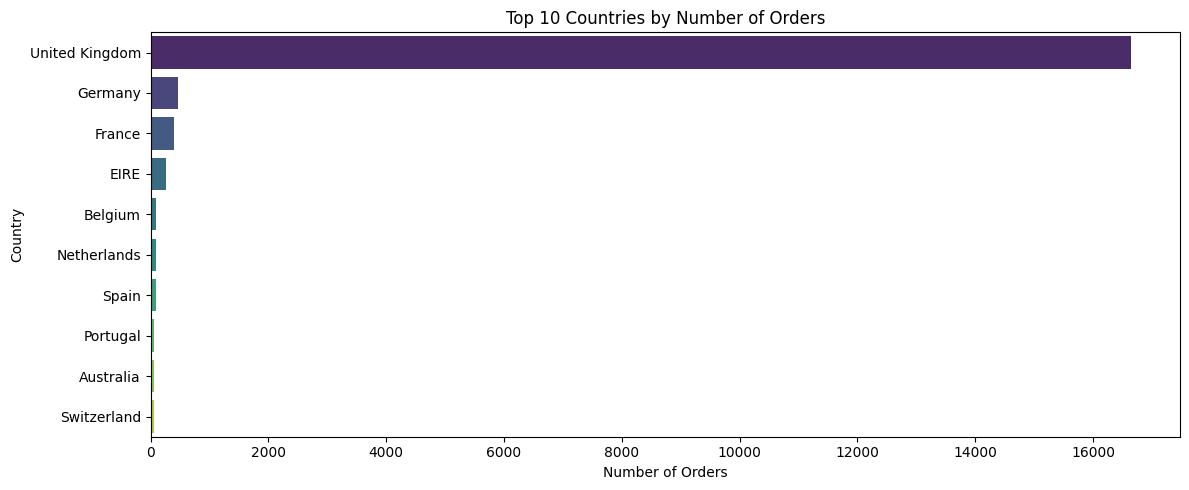

In [27]:
# ── 1. TOP 10 COUNTRIES BY ORDERS ─────────────────
plt.figure(figsize=(12,5))
top_countries = df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Number of Orders')
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.show()

### 2️⃣ Top 10 products

C:\Users\Parth\AppData\Local\Temp\ipykernel_5384\1078655146.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='magma')


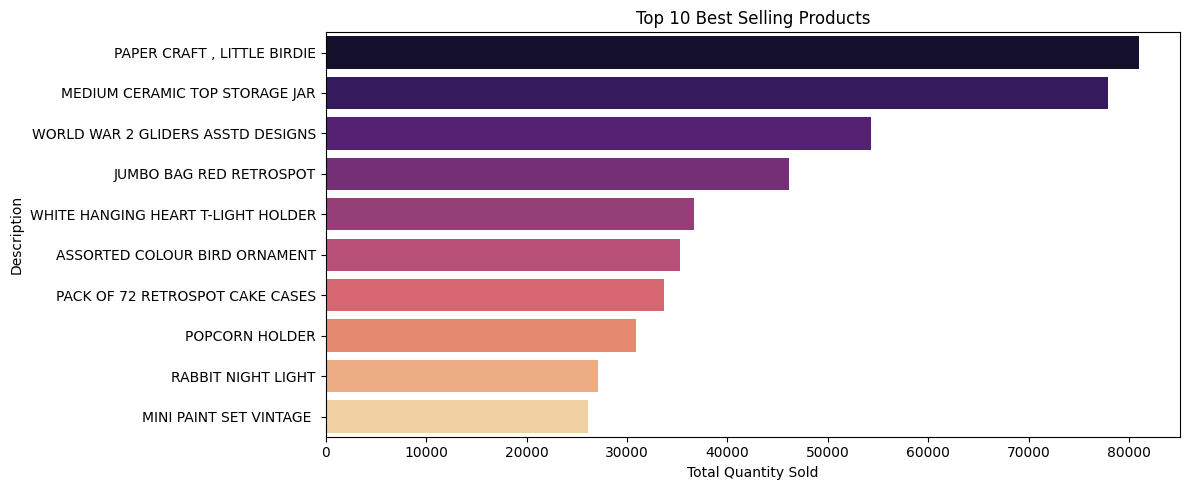

In [28]:
plt.figure(figsize=(12,5))
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index, palette='magma')
plt.title('Top 10 Best Selling Products')
plt.xlabel('Total Quantity Sold')
plt.tight_layout()
plt.show()

### 3️⃣ Monthly purchase trend

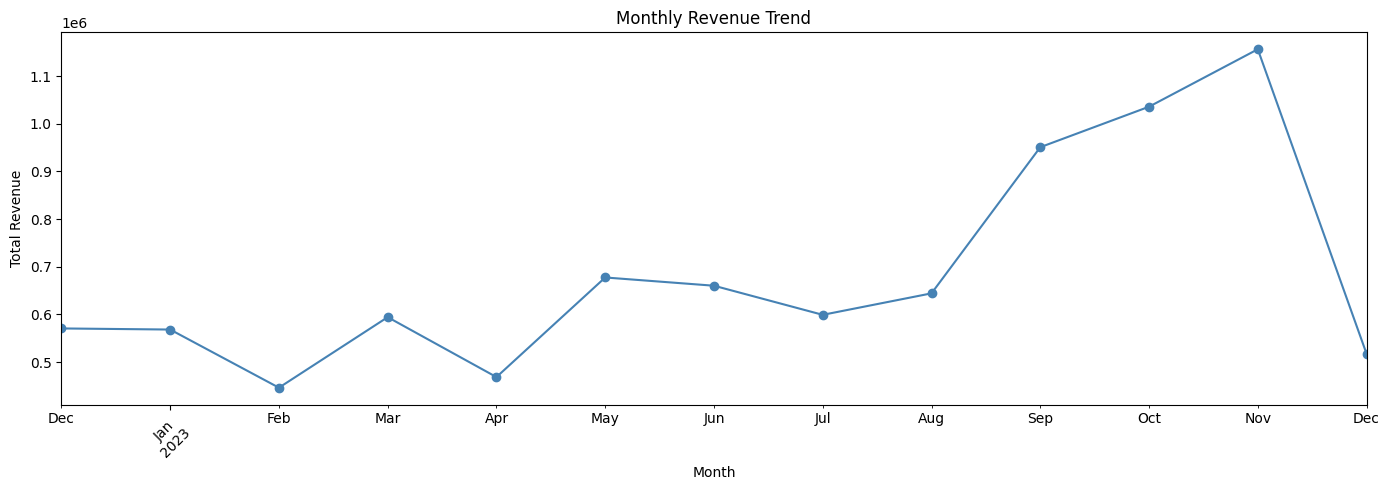

In [29]:
plt.figure(figsize=(14,5))
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly = df.groupby('Month')['TotalPrice'].sum()
monthly.plot(kind='line', marker='o', color='steelblue')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4️⃣ Monetary distribution per transaction

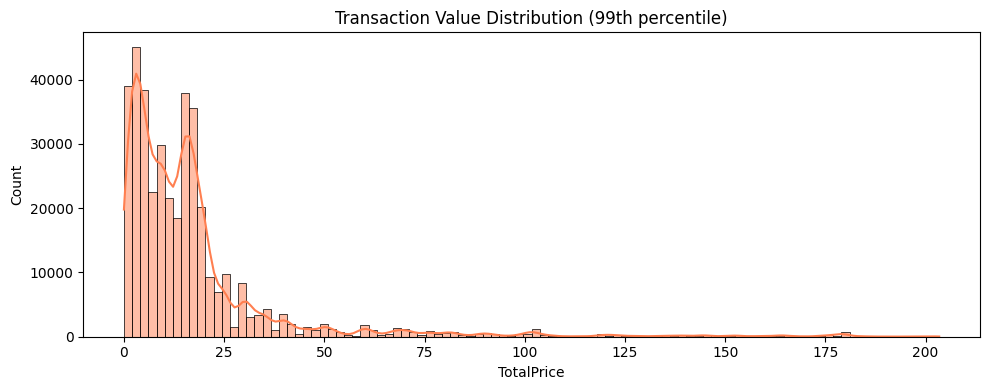

In [30]:
plt.figure(figsize=(10,4))
df_plot = df[df['TotalPrice'] < df['TotalPrice'].quantile(0.99)]  # remove outliers for viz
sns.histplot(df_plot['TotalPrice'], bins=100, kde=True, color='coral')
plt.title('Transaction Value Distribution (99th percentile)')
plt.xlabel('TotalPrice')
plt.tight_layout()
plt.show()

In [31]:
print("Total Revenue: £{:,.2f}".format(df['TotalPrice'].sum()))
print("Unique Customers:", df['CustomerID'].nunique())
print("Unique Products:", df['Description'].nunique())
print("Date Range:", df['InvoiceDate'].min(), "→", df['InvoiceDate'].max())

Total Revenue: £8,887,208.89
Unique Customers: 4338
Unique Products: 3877
Date Range: 2022-12-01 08:26:00 → 2023-12-09 12:50:00


### 5️⃣ Quarter wise selling trend

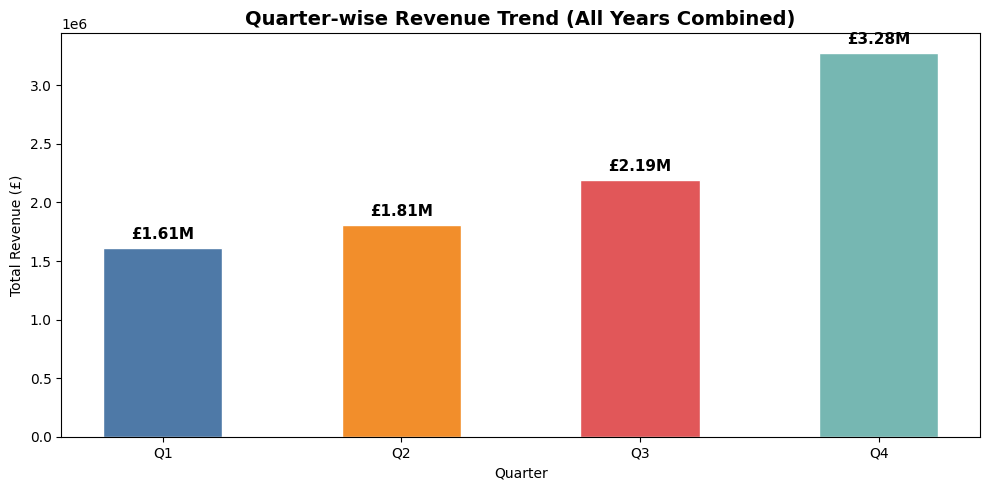

In [34]:
plt.figure(figsize=(10,5))
df['QuarterOnly'] = df['InvoiceDate'].dt.quarter.map({1:'Q1', 2:'Q2', 3:'Q3', 4:'Q4'})
quarterly = df.groupby('QuarterOnly')['TotalPrice'].sum().reindex(['Q1','Q2','Q3','Q4'])
bars = plt.bar(['Q1','Q2','Q3','Q4'], quarterly.values, color=['#4E79A7','#F28E2B','#E15759','#76B7B2'], width=0.5, edgecolor='white')

for bar, val in zip(bars, quarterly.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
             f'£{val/1e6:.2f}M', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title('Quarter-wise Revenue Trend (All Years Combined)', fontsize=14, fontweight='bold')
plt.xlabel('Quarter')
plt.ylabel('Total Revenue (£)')
plt.tight_layout()
plt.show()

### 6️⃣ Average selling performance in a day

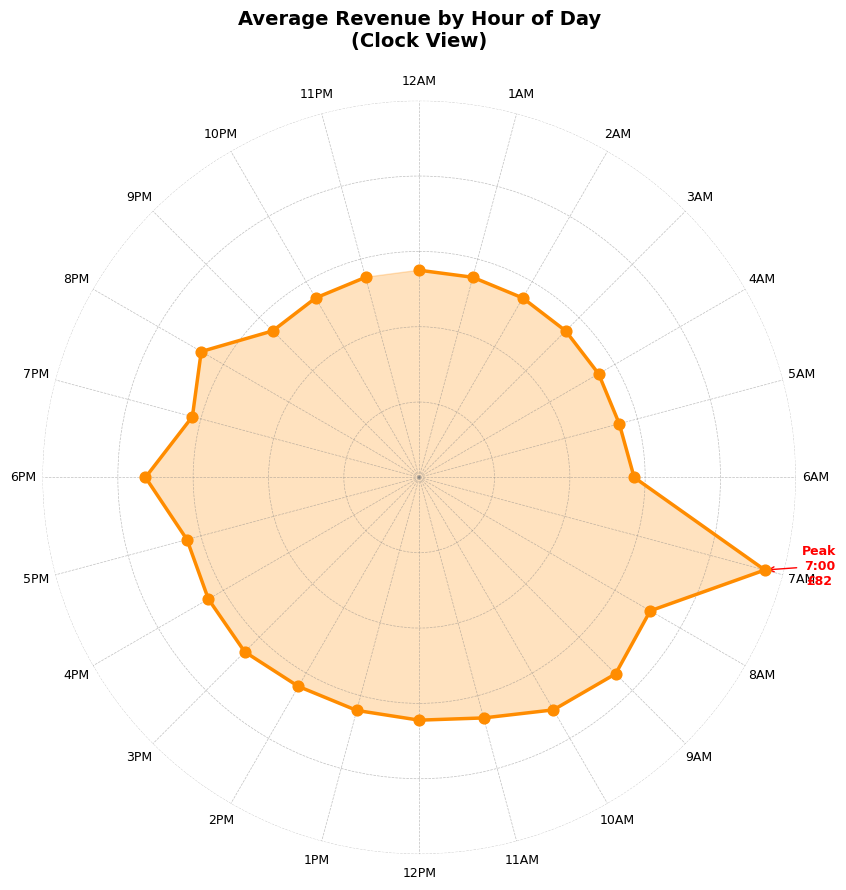

Peak Hour: 7 → Avg £81.95
Dead Hour: 0 → Avg £0.00


In [35]:
df['Hour'] = df['InvoiceDate'].dt.hour
hourly = df.groupby('Hour')['TotalPrice'].mean().reindex(range(24), fill_value=0)

# polar coordinates
hours = np.arange(24)
angles = np.linspace(0, 2 * np.pi, 24, endpoint=False)

# normalize values for radius
values = hourly.values
norm_values = (values - values.min()) / (values.max() - values.min()) * 0.4 + 0.55

fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))

# rotate so 0 (midnight) at top, clockwise
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

# fill area
ax.fill(angles, norm_values, alpha=0.25, color='darkorange')
ax.plot(angles, norm_values, color='darkorange', linewidth=2.5)

# dots at each hour
ax.scatter(angles, norm_values, color='darkorange', s=60, zorder=5)

# hour labels on border (like clock)
ax.set_xticks(angles)
ax.set_xticklabels([
    '12AM','1AM','2AM','3AM','4AM','5AM',
    '6AM','7AM','8AM','9AM','10AM','11AM',
    '12PM','1PM','2PM','3PM','4PM','5PM',
    '6PM','7PM','8PM','9PM','10PM','11PM'
], fontsize=9)

# hide radial labels
ax.set_yticklabels([])
ax.set_ylim(0, 1)

# grid style
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
ax.spines['polar'].set_visible(False)

# annotate peak hour
peak_hour = hourly.idxmax()
peak_angle = angles[peak_hour]
peak_val = norm_values[peak_hour]
ax.annotate(f'Peak\n{peak_hour}:00\n£{hourly[peak_hour]:.0f}',
            xy=(peak_angle, peak_val),
            xytext=(peak_angle, peak_val + 0.15),
            fontsize=9, color='red', fontweight='bold',
            ha='center',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_title('Average Revenue by Hour of Day\n(Clock View)', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("Peak Hour:", peak_hour, "→ Avg £{:.2f}".format(hourly[peak_hour]))
print("Dead Hour:", hourly.idxmin(), "→ Avg £{:.2f}".format(hourly.min()))

In [36]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month,Quarter,Hour,QuarterOnly
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2022-12,2022Q4,8,Q4
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2022-12,2022Q4,8,Q4
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2022-12,2022Q4,8,Q4
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2022-12,2022Q4,8,Q4
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2022-12,2022Q4,8,Q4


$$ \LARGE \text{3. Feature Engineering and RFM table design} $$
---

### 1️⃣ RFM Calculation

In [38]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

In [39]:
print("RFM Shape:", rfm.shape)

RFM Shape: (4338, 4)


In [40]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


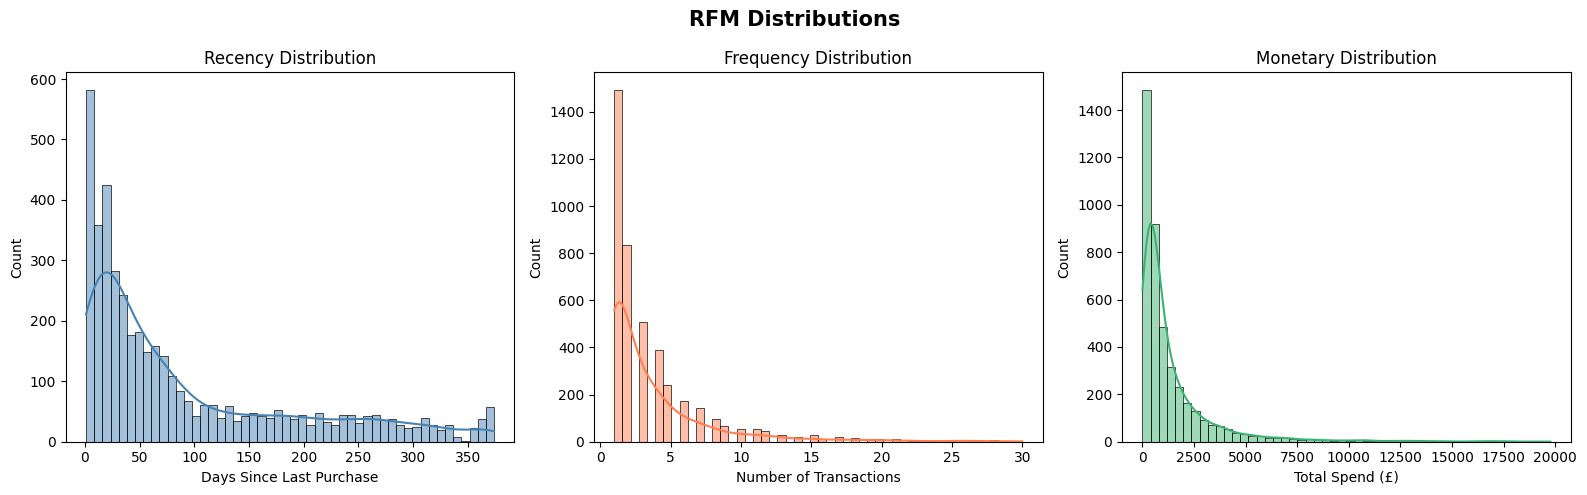

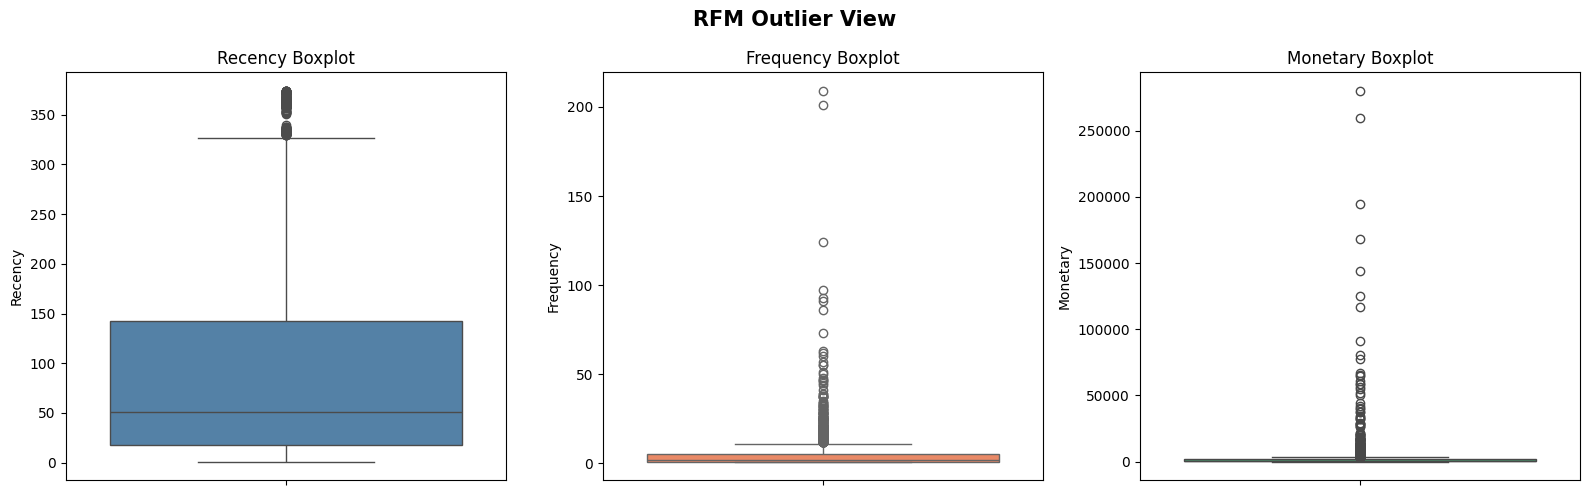

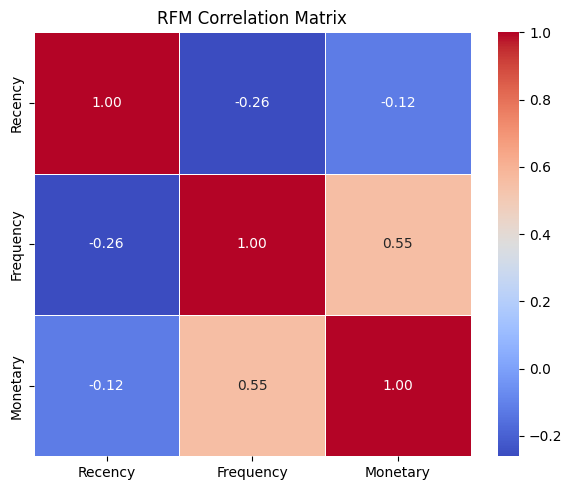

=== RFM STATS ===
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2048.69
std     100.01       7.70    8985.23
min       1.00       1.00       3.75
25%      18.00       1.00     306.48
50%      51.00       2.00     668.57
75%     142.00       5.00    1660.60
max     374.00     209.00  280206.02

Outliers (Monetary > 99th pct): 44
Outliers (Frequency > 99th pct): 42


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# R distribution
sns.histplot(rfm['Recency'], bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days Since Last Purchase')

# F distribution (cap at 99th percentile for viz)
f_cap = rfm['Frequency'].quantile(0.99)
sns.histplot(rfm[rfm['Frequency'] <= f_cap]['Frequency'], bins=50, kde=True, color='coral', ax=axes[1])
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of Transactions')

# M distribution (cap at 99th percentile for viz)
m_cap = rfm['Monetary'].quantile(0.99)
sns.histplot(rfm[rfm['Monetary'] <= m_cap]['Monetary'], bins=50, kde=True, color='mediumseagreen', ax=axes[2])
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total Spend (£)')

plt.suptitle('RFM Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── BOXPLOTS ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(y=rfm['Recency'],   color='steelblue',      ax=axes[0])
sns.boxplot(y=rfm['Frequency'], color='coral',           ax=axes[1])
sns.boxplot(y=rfm['Monetary'],  color='mediumseagreen',  ax=axes[2])

axes[0].set_title('Recency Boxplot')
axes[1].set_title('Frequency Boxplot')
axes[2].set_title('Monetary Boxplot')

plt.suptitle('RFM Outlier View', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── CORRELATION ───────────────────────────────────
plt.figure(figsize=(6,5))
sns.heatmap(rfm[['Recency','Frequency','Monetary']].corr(), 
            annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('RFM Correlation Matrix')
plt.tight_layout()
plt.show()

# ── QUICK STATS ───────────────────────────────────
print("=== RFM STATS ===")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))
print("\nOutliers (Monetary > 99th pct):", (rfm['Monetary'] > m_cap).sum())
print("Outliers (Frequency > 99th pct):", (rfm['Frequency'] > f_cap).sum())

In [42]:
# ── OUTLIER PERCENTAGE CHECK ──────────────────────
for col in ['Recency', 'Frequency', 'Monetary']:
    Q1 = rfm[col].quantile(0.25)
    Q3 = rfm[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = rfm[(rfm[col] < lower) | (rfm[col] > upper)]
    pct = (len(outliers) / len(rfm)) * 100
    
    print(f"{col}:")
    print(f"  Lower bound : {lower:.2f}")
    print(f"  Upper bound : {upper:.2f}")
    print(f"  Outlier count: {len(outliers)}")
    print(f"  Outlier %   : {pct:.2f}%")
    print()

Recency:
  Lower bound : -168.00
  Upper bound : 328.00
  Outlier count: 155
  Outlier %   : 3.57%

Frequency:
  Lower bound : -5.00
  Upper bound : 11.00
  Outlier count: 285
  Outlier %   : 6.57%

Monetary:
  Lower bound : -1724.69
  Upper bound : 3691.77
  Outlier count: 425
  Outlier %   : 9.80%



$$ \LARGE \text{4. Data Transformation} $$
---

In [44]:
rfm['Frequency'] = winsorize(rfm['Frequency'], limits=[0.01, 0.01])
rfm['Monetary']  = winsorize(rfm['Monetary'],  limits=[0.01, 0.01])

rfm['Recency_log']   = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log']  = np.log1p(rfm['Monetary'])

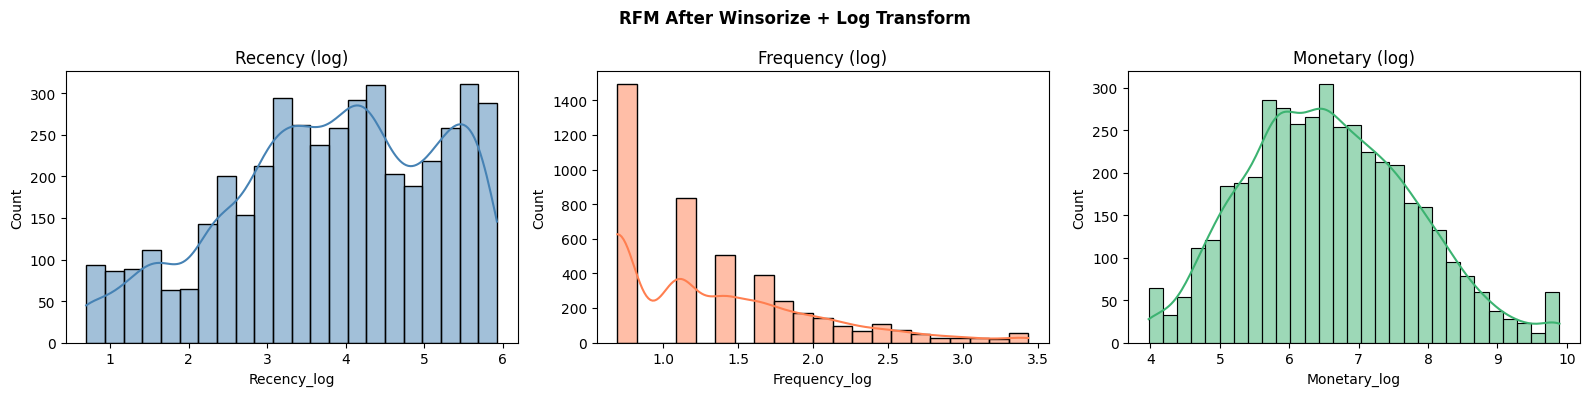

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
sns.histplot(rfm['Recency_log'],   kde=True, ax=axes[0], color='steelblue').set_title('Recency (log)')
sns.histplot(rfm['Frequency_log'], kde=True, ax=axes[1], color='coral').set_title('Frequency (log)')
sns.histplot(rfm['Monetary_log'],  kde=True, ax=axes[2], color='mediumseagreen').set_title('Monetary (log)')
plt.suptitle('RFM After Winsorize + Log Transform', fontweight='bold')
plt.tight_layout()
plt.show()

In [47]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency_log', 'Frequency_log', 'Monetary_log']])

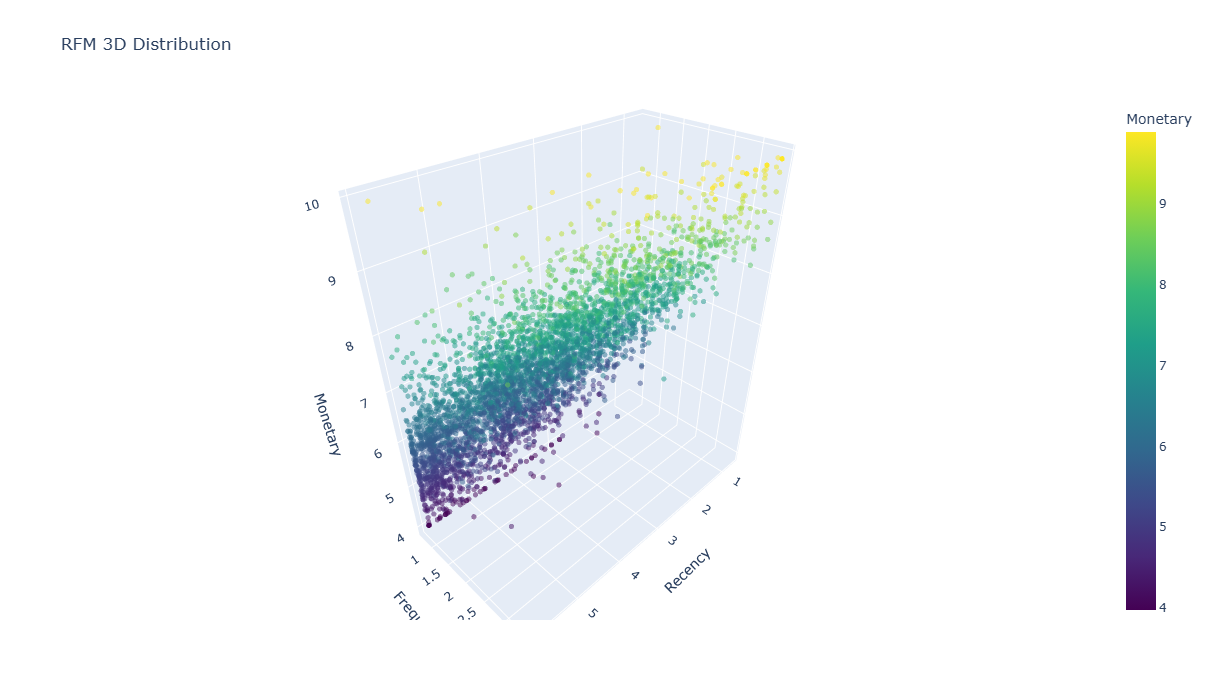

In [53]:
fig = px.scatter_3d(
    rfm,
    x='Recency_log',
    y='Frequency_log',
    z='Monetary_log',
    opacity=0.5,
    color='Monetary_log',
    color_continuous_scale='Viridis',
    title='RFM 3D Distribution',
    labels={
        'Recency_log'  : 'Recency',
        'Frequency_log': 'Frequency',
        'Monetary_log' : 'Monetary'
    }
)

fig.update_traces(marker=dict(size=3))
fig.update_layout(width=900, height=700)
fig.show()

$$ \LARGE \text {5. Model Tuning, Building and Selection} $$
---

### **1️⃣ `KMeans`**

In [48]:
inertia = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))

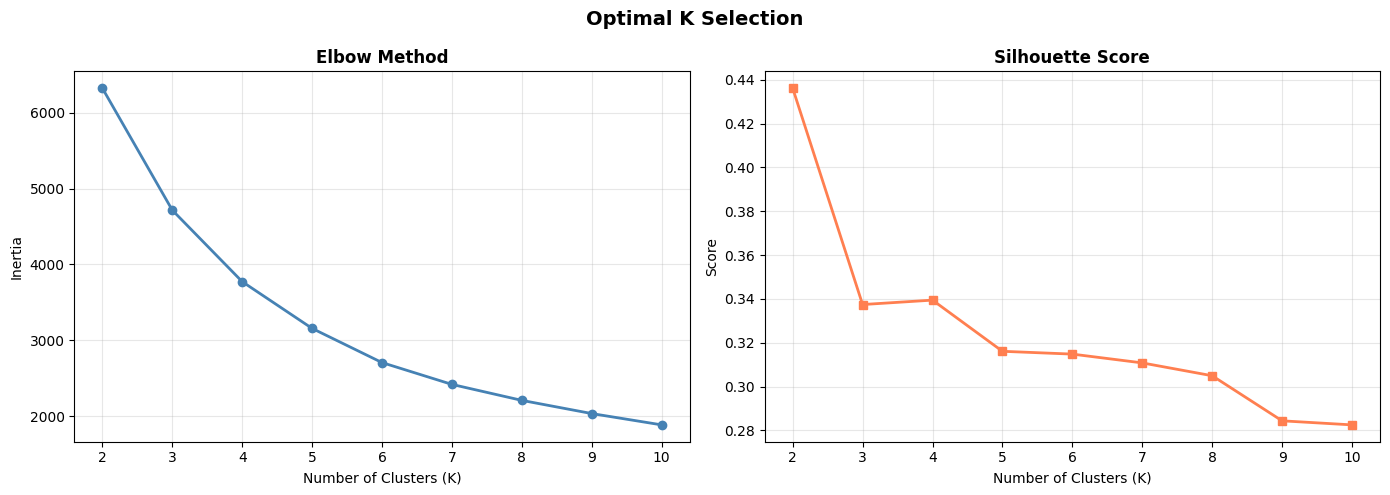

K  | Inertia    | Silhouette
-----------------------------------
K=2 |    6322.28 | 0.4361
K=3 |    4715.09 | 0.3374
K=4 |    3773.07 | 0.3394
K=5 |    3157.03 | 0.3161
K=6 |    2706.91 | 0.3148
K=7 |    2419.37 | 0.3108
K=8 |    2208.94 | 0.3049
K=9 |    2035.21 | 0.2843
K=10 |    1886.18 | 0.2825

Best K by Silhouette: 2


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(K_range, inertia, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(K_range)
axes[0].grid(alpha=0.3)

# Silhouette
axes[1].plot(K_range, sil_scores, marker='s', color='coral', linewidth=2)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Score')
axes[1].set_xticks(K_range)
axes[1].grid(alpha=0.3)

plt.suptitle('Optimal K Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── PRINT SCORES ──────────────────────────────────
print("K  | Inertia    | Silhouette")
print("-" * 35)
for k, i, s in zip(K_range, inertia, sil_scores):
    print(f"K={k} | {i:10.2f} | {s:.4f}")

print("\nBest K by Silhouette:", K_range[sil_scores.index(max(sil_scores))])

### **2️⃣ `AgglomerativeClustering`**

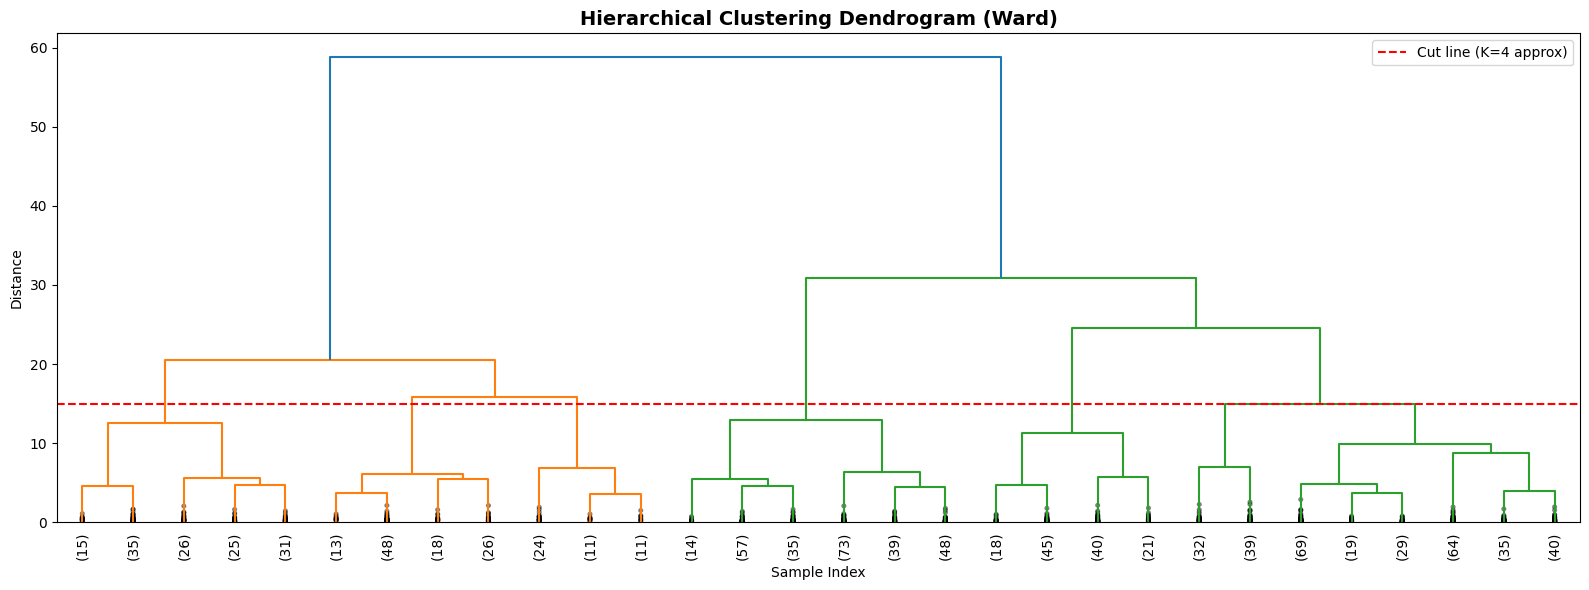

In [55]:
# ── STEP 1: DENDROGRAM (sample 1000, full data too heavy) ──
sample = rfm[['Recency_log','Frequency_log','Monetary_log']].sample(1000, random_state=42)

plt.figure(figsize=(16, 6))
dendrogram = sch.dendrogram(
    sch.linkage(sample, method='ward'),
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)
plt.title('Hierarchical Clustering Dendrogram (Ward)', fontweight='bold', fontsize=14)
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.axhline(y=15, color='red', linestyle='--', label='Cut line (K=4 approx)')
plt.legend()
plt.tight_layout()
plt.show()

In [56]:

# ── STEP 2: FIT AGGLOMERATIVE K=2 to 8 ────────────────────
print("K  | Silhouette")
print("-" * 20)
sil_agg = []
K_range = range(2, 9)

for k in K_range:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    sil_agg.append(score)
    print(f"K={k} | {score:.4f}")

best_k = K_range[sil_agg.index(max(sil_agg))]
print(f"\nBest K: {best_k} → Silhouette: {max(sil_agg):.4f}")

K  | Silhouette
--------------------
K=2 | 0.4146
K=3 | 0.3299
K=4 | 0.2462
K=5 | 0.2562
K=6 | 0.2527
K=7 | 0.2465
K=8 | 0.2144

Best K: 2 → Silhouette: 0.4146


In [57]:
# ── STEP 3: FIT FINAL WITH BEST K ─────────────────────────
agg_final = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
rfm['Agg_Cluster'] = agg_final.fit_predict(rfm_scaled)

# ── STEP 4: CLUSTER PROFILE ────────────────────────────────
profile = rfm.groupby('Agg_Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
print("\nCluster Profiles:")
print(profile)


Cluster Profiles:
             Recency  Frequency  Monetary
Agg_Cluster                              
0              18.84       7.86   3368.55
1             132.89       1.90    620.24


### **3️⃣ `DBSCAN`**

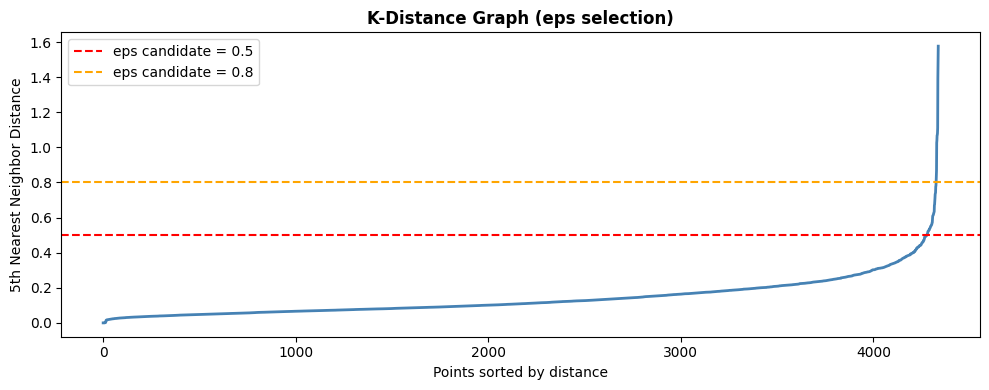

In [60]:
# ── DBSCAN PARAMETER SEARCH ───────────────────────
# Find good eps using k-distance graph


neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(rfm_scaled)
distances, _ = neighbors.kneighbors(rfm_scaled)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(10, 4))
plt.plot(distances, color='steelblue', linewidth=2)
plt.title('K-Distance Graph (eps selection)', fontweight='bold')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.axhline(y=0.5, color='red', linestyle='--', label='eps candidate = 0.5')
plt.axhline(y=0.8, color='orange', linestyle='--', label='eps candidate = 0.8')
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
# ── TRY MULTIPLE eps + min_samples ────────────────
print("eps  | min_s | Clusters | Noise% | Silhouette")
print("-" * 55)

results = []
for eps in [0.3, 0.5, 0.8, 1.0, 1.2]:
    for min_s in [5, 10, 15]:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(rfm_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = (labels == -1).sum() / len(labels) * 100
        
        if n_clusters >= 2:
            # silhouette only on non-noise points
            mask = labels != -1
            if mask.sum() > 100:
                sil = silhouette_score(rfm_scaled[mask], labels[mask])
            else:
                sil = -1
        else:
            sil = -1
            
        print(f"{eps:.1f}  |  {min_s:2d}   |    {n_clusters:2d}    | {noise_pct:5.1f}% | {sil:.4f}")
        results.append((eps, min_s, n_clusters, noise_pct, sil))

eps  | min_s | Clusters | Noise% | Silhouette
-------------------------------------------------------
0.3  |   5   |    15    |   4.4% | 0.0527
0.3  |  10   |     9    |   9.6% | 0.0999
0.3  |  15   |     4    |  15.8% | 0.1563
0.5  |   5   |     2    |   0.6% | 0.2925
0.5  |  10   |     2    |   0.9% | 0.2939
0.5  |  15   |     2    |   1.4% | 0.2959
0.8  |   5   |     1    |   0.2% | -1.0000
0.8  |  10   |     1    |   0.2% | -1.0000
0.8  |  15   |     1    |   0.2% | -1.0000
1.0  |   5   |     1    |   0.0% | -1.0000
1.0  |  10   |     1    |   0.0% | -1.0000
1.0  |  15   |     1    |   0.1% | -1.0000
1.2  |   5   |     1    |   0.0% | -1.0000
1.2  |  10   |     1    |   0.0% | -1.0000
1.2  |  15   |     1    |   0.0% | -1.0000


## **👩‍⚖️ Decision**
- **KMeans is giving good results for `K=2` but since requirement is of 4 clusters, than i will go with `K=4`**
- **Although silhoutte score for K=4 is low but not bad.**

In [63]:
# ── FIT FINAL KMEANS K=4 ──────────────────────────
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

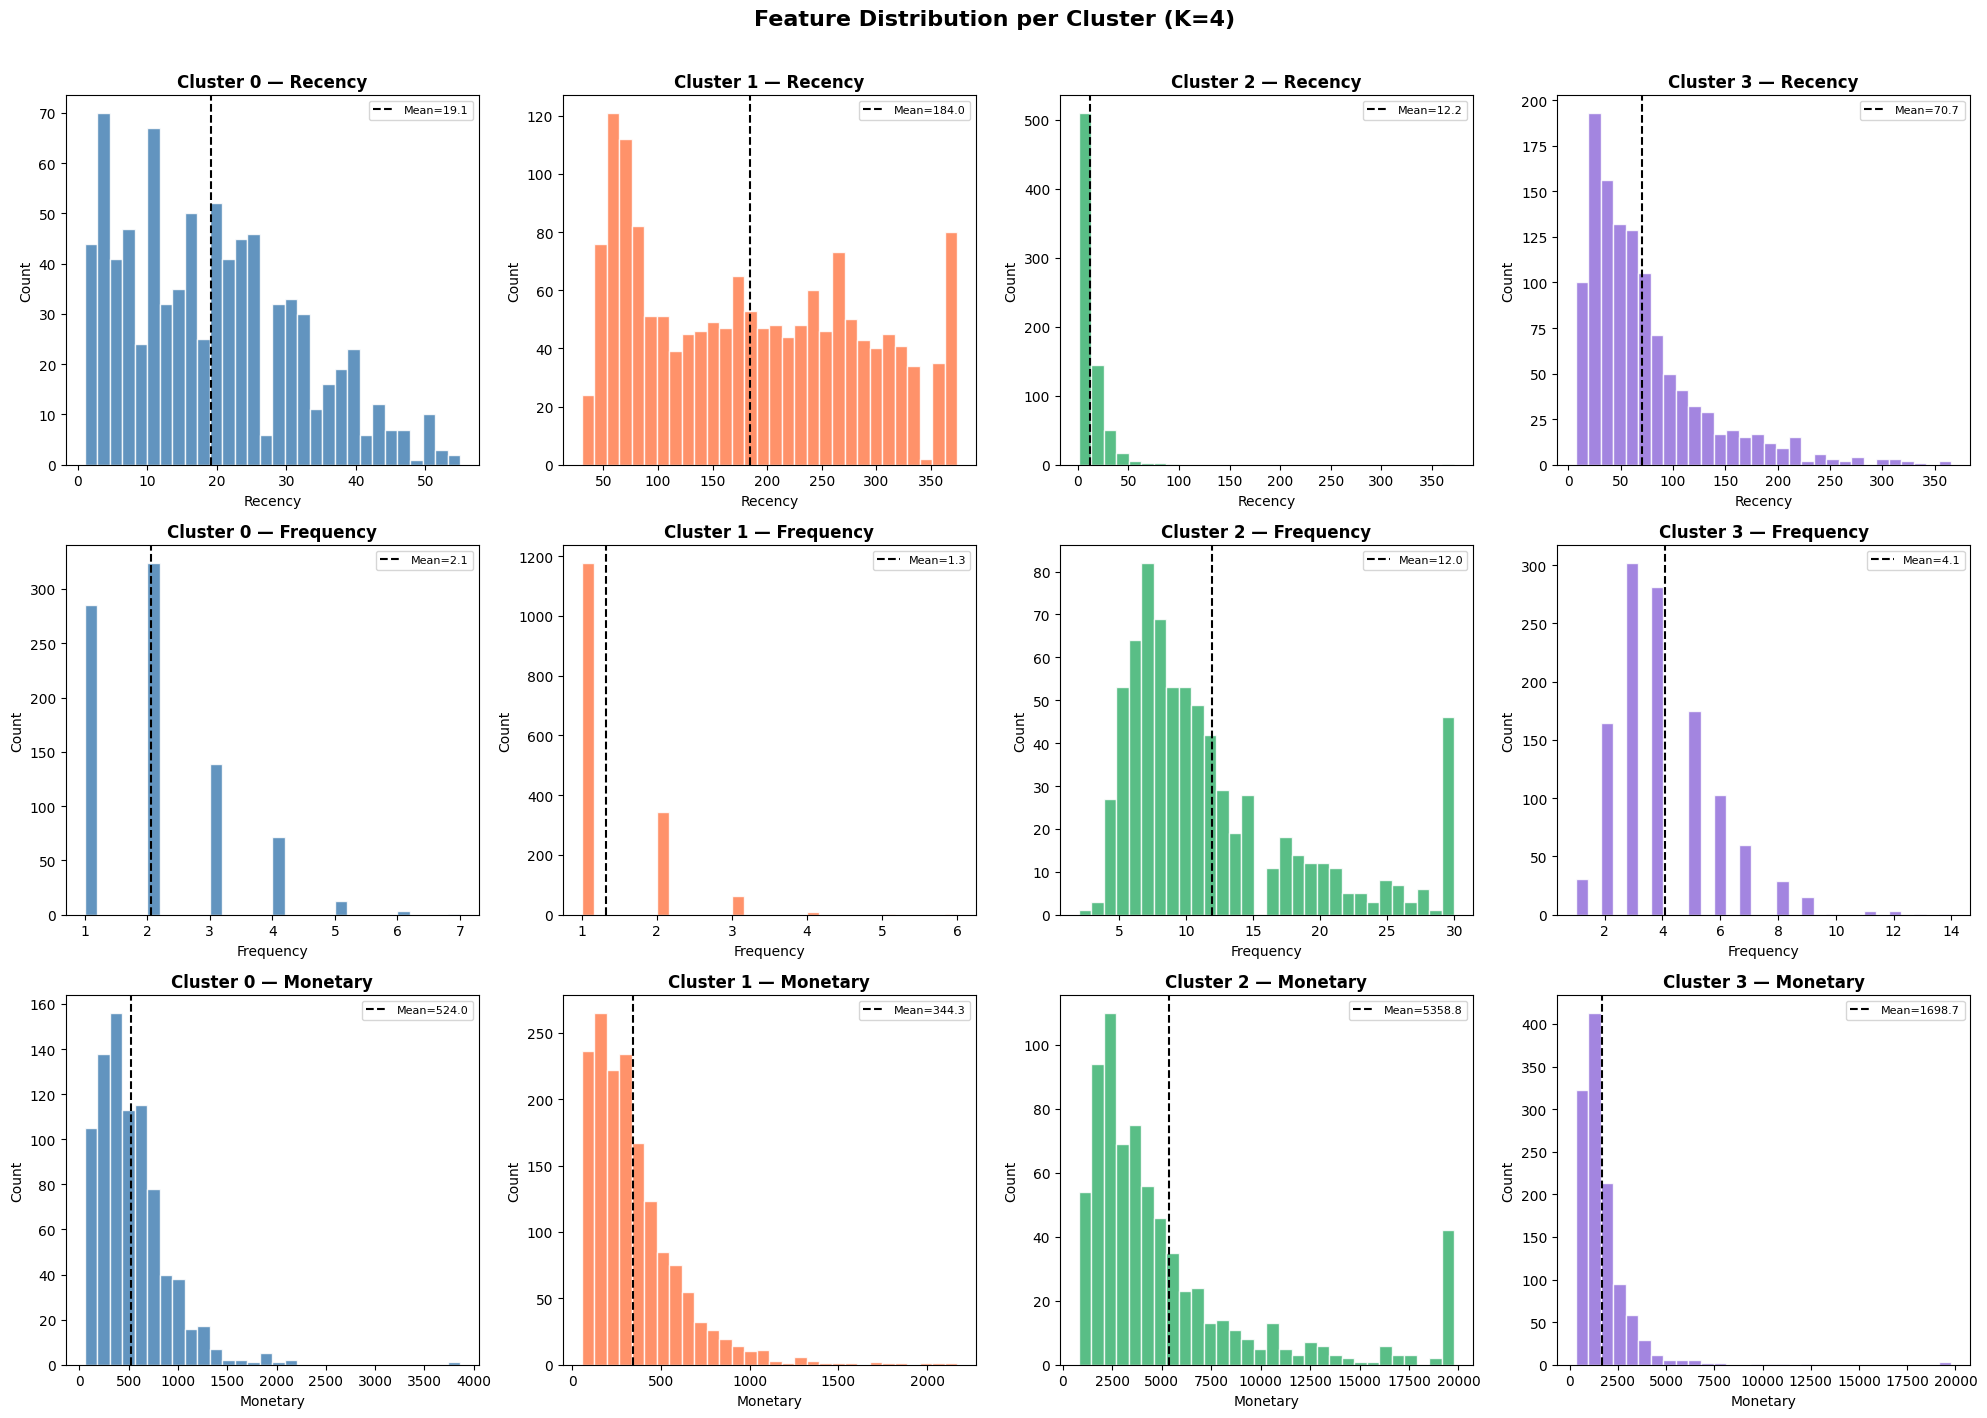

In [64]:
# ── VISUALIZE DISTRIBUTION PER CLUSTER ────────────
fig, axes = plt.subplots(3, 4, figsize=(20, 14))

features = ['Recency', 'Frequency', 'Monetary']
colors   = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

for row, feature in enumerate(features):
    for col in range(4):
        cluster_data = rfm[rfm['Cluster'] == col][feature]
        
        axes[row, col].hist(cluster_data, bins=30, 
                            color=colors[col], 
                            edgecolor='white', 
                            alpha=0.85)
        axes[row, col].set_title(f'Cluster {col} — {feature}', fontweight='bold')
        axes[row, col].set_xlabel(feature)
        axes[row, col].set_ylabel('Count')
        axes[row, col].axvline(cluster_data.mean(), 
                               color='black', 
                               linestyle='--', 
                               linewidth=1.5,
                               label=f'Mean={cluster_data.mean():.1f}')
        axes[row, col].legend(fontsize=8)

plt.suptitle('Feature Distribution per Cluster (K=4)', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [66]:
# ── PROFILE TABLE ─────────────────────────────────
profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].agg(['mean','median']).round(2)
print(profile)

        Recency        Frequency        Monetary         
           mean median      mean median     mean   median
Cluster                                                  
0         19.12   18.0      2.06    2.0   524.04   454.86
1        183.98  178.0      1.32    1.0   344.28   296.64
2         12.18    8.0     11.96   10.0  5358.82  3668.50
3         70.65   55.0      4.08    4.0  1698.66  1338.56


In [67]:
print("\nCluster Sizes:")
print(rfm['Cluster'].value_counts().sort_index())


Cluster Sizes:
Cluster
0     837
1    1597
2     734
3    1170
Name: count, dtype: int64


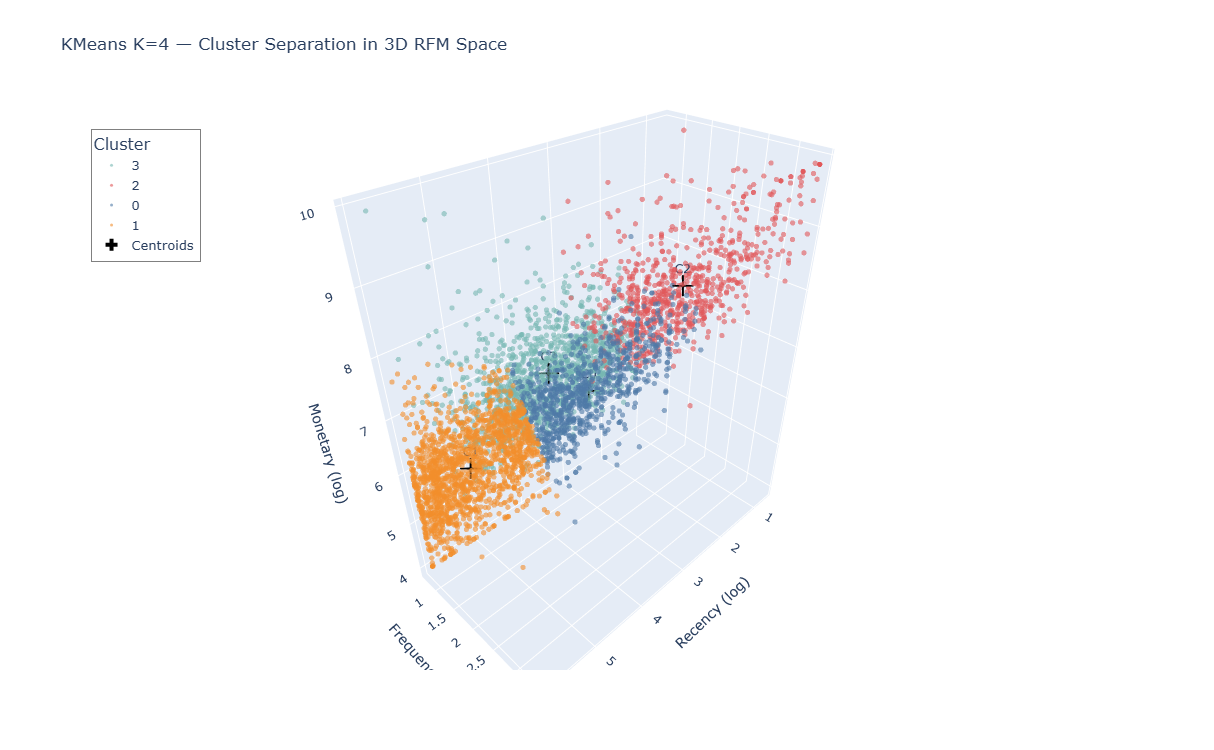

In [71]:
# ── FIX: discrete color + clean legend ────────────
rfm['Cluster_str'] = rfm['Cluster'].astype(str)

fig = px.scatter_3d(
    rfm,
    x='Recency_log',
    y='Frequency_log',
    z='Monetary_log',
    color='Cluster_str',
    color_discrete_map={
        '0': '#4E79A7',
        '1': '#F28E2B',
        '2': '#E15759',
        '3': '#76B7B2'
    },
    opacity=0.6,
    title='KMeans K=4 — Cluster Separation in 3D RFM Space',
    labels={
        'Recency_log'  : 'Recency (log)',
        'Frequency_log': 'Frequency (log)',
        'Monetary_log' : 'Monetary (log)',
        'Cluster_str'  : 'Cluster'
    }
)

# ── CENTROIDS ─────────────────────────────────────
centroids_log = scaler.inverse_transform(km_final.cluster_centers_)

fig.add_trace(go.Scatter3d(
    x=centroids_log[:, 0],
    y=centroids_log[:, 1],
    z=centroids_log[:, 2],
    mode='markers+text',
    marker=dict(size=10, color='black', symbol='cross'),
    text=[f'C{i}' for i in range(4)],
    textposition='top center',
    name='Centroids'
))

fig.update_traces(marker=dict(size=3), selector=dict(mode='markers'))

fig.update_layout(
    width=950,
    height=750,
    coloraxis_showscale=False,   # ← removes side color scale bar
    legend=dict(
        title='Cluster',
        x=0.01,
        y=0.95,
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='grey',
        borderwidth=1,
        font=dict(size=13)
    ),
    scene=dict(
        xaxis_title='Recency (log)',
        yaxis_title='Frequency (log)',
        zaxis_title='Monetary (log)'
    )
)

fig.show()

In [87]:
print("Cluster label assignment table")
label_map = {
    2: 'High-Value',
    3: 'Regular',
    0: 'Occasional',
    1: 'At-Risk'
}

rfm['Segment'] = rfm['Cluster'].map(label_map)

# ── VERIFY ────────────────────────────────────────
print(rfm['Segment'].value_counts())

Cluster label assignment table
Segment
At-Risk       1597
Regular       1170
Occasional     837
High-Value     734
Name: count, dtype: int64


In [88]:
joblib.dump(label_map, f'{SOURCE_PATH}/label_map.pkl')
print("Label map saved.")

Label map saved.


In [85]:
# ── CLUSTER PROFILE ───────────────────────────────
profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
print(profile)
print("\nCluster Sizes:")
print(rfm['Cluster'].value_counts().sort_index())

         Recency  Frequency  Monetary
Cluster                              
0          19.12       2.06    524.04
1         183.98       1.32    344.28
2          12.18      11.96   5358.82
3          70.65       4.08   1698.66

Cluster Sizes:
Cluster
0     837
1    1597
2     734
3    1170
Name: count, dtype: int64


$$ \LARGE \text{6. Dumping final model} $$
---

In [68]:
SOURCE_PATH = "../models"
joblib.dump(km_final, f'{SOURCE_PATH}/kmeans_model.pkl')
joblib.dump(scaler,   f'{SOURCE_PATH}/scaler.pkl')
print("\nModels saved.")


Models saved.


# **🔥 `Phase-2` Product Recommendation Model Development**

In [73]:
pivot = df.groupby(['CustomerID', 'Description'])['Quantity'].sum().unstack(fill_value=0)
print("Pivot shape:", pivot.shape)

Pivot shape: (4338, 3877)


In [77]:
pivot

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18280,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18281,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
18282,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [78]:
# ── STEP 2: COSINE SIMILARITY BETWEEN PRODUCTS ────
# Transpose → products as rows
product_matrix = pivot.T

cos_sim = cosine_similarity(product_matrix)
cos_sim_df = pd.DataFrame(
    cos_sim,
    index=product_matrix.index,
    columns=product_matrix.index
)

print("Similarity matrix shape:", cos_sim_df.shape)

Similarity matrix shape: (3877, 3877)


In [79]:
# ── STEP 3: RECOMMENDATION FUNCTION ───────────────
def recommend_products(product_name, n=5):
    if product_name not in cos_sim_df.index:
        return f"Product '{product_name}' not found."
    
    similar = cos_sim_df[product_name].sort_values(ascending=False)
    similar = similar.drop(product_name)  # remove itself
    return similar.head(n).index.tolist()

In [80]:
# ── STEP 4: TEST ───────────────────────────────────
test_product = df['Description'].value_counts().index[0]  # most popular product
print(f"\nTest product: {test_product}")
print("Recommendations:")
for i, p in enumerate(recommend_products(test_product), 1):
    print(f"  {i}. {p}")


Test product: WHITE HANGING HEART T-LIGHT HOLDER
Recommendations:
  1. GIN + TONIC DIET METAL SIGN
  2. RED HANGING HEART T-LIGHT HOLDER
  3. WASHROOM METAL SIGN
  4. LAUNDRY 15C METAL SIGN
  5. GREEN VINTAGE SPOT BEAKER


In [82]:
# ── STEP 5: SAVE ───────────────────────────────────
joblib.dump(cos_sim_df, f'{SOURCE_PATH}/similarity_matrix.pkl')
print("\nSimilarity matrix saved.")


Similarity matrix saved.


In [84]:
joblib.dump(cos_sim_df.index.tolist(), f'{SOURCE_PATH}/product_list.pkl')
print("\nProduct list saved.")


Product list saved.


In [83]:
# ── VERIFY RECOMMENDATIONS LOGICALLY ──────────────

def recommend_with_scores(product_name, n=5):
    if product_name not in cos_sim_df.index:
        return f"Product '{product_name}' not found."
    
    similar = cos_sim_df[product_name].sort_values(ascending=False)
    similar = similar.drop(product_name)
    top = similar.head(n)
    
    print(f"\nInput Product: {product_name}")
    print(f"{'Rank':<5} {'Score':<8} {'Product'}")
    print("-" * 60)
    for i, (prod, score) in enumerate(top.items(), 1):
        print(f"{i:<5} {score:.4f}   {prod}")

# ── TEST ON 5 DIFFERENT POPULAR PRODUCTS ──────────
top5_products = df['Description'].value_counts().head(5).index.tolist()

for product in top5_products:
    recommend_with_scores(product)
    print()

# ── ALSO CHECK: WHO BOUGHT BOTH PRODUCTS ──────────
def common_buyers(p1, p2):
    buyers_p1 = set(pivot[pivot[p1] > 0].index)
    buyers_p2 = set(pivot[pivot[p2] > 0].index)
    common = buyers_p1 & buyers_p2
    print(f"\nCommon buyers of '{p1}' & '{p2}': {len(common)}")
    return common

# verify top recommendation of first product
top_products = df['Description'].value_counts().head(1).index.tolist()
recs = recommend_products(top_products[0])
common_buyers(top_products[0], recs[0])


Input Product: WHITE HANGING HEART T-LIGHT HOLDER
Rank  Score    Product
------------------------------------------------------------
1     0.7502   GIN + TONIC DIET METAL SIGN
2     0.6587   RED HANGING HEART T-LIGHT HOLDER
3     0.6435   WASHROOM METAL SIGN
4     0.6422   LAUNDRY 15C METAL SIGN
5     0.6315   GREEN VINTAGE SPOT BEAKER


Input Product: REGENCY CAKESTAND 3 TIER
Rank  Score    Product
------------------------------------------------------------
1     0.7016   MINI PLAYING CARDS FUN FAIR 
2     0.6993   BOX OF 6 CHRISTMAS CAKE DECORATIONS
3     0.6911   BLACK LOVE BIRD T-LIGHT HOLDER
4     0.6909   MIRROR LOVE BIRD T-LIGHT HOLDER
5     0.6846   BLUE POLKADOT WRAP


Input Product: JUMBO BAG RED RETROSPOT
Rank  Score    Product
------------------------------------------------------------
1     0.9006   JUMBO BAG STRAWBERRY
2     0.8955   JUMBO BAG PINK POLKADOT
3     0.8010   JUMBO BAG OWLS
4     0.7883   JUMBO BAG PINK VINTAGE PAISLEY
5     0.7613   JUMBO BAG APPLES


In

{12540,
 12744,
 12748,
 12872,
 13000,
 13089,
 13168,
 13186,
 13225,
 13263,
 13458,
 13468,
 13515,
 13569,
 13571,
 13607,
 13634,
 13668,
 13680,
 13769,
 13782,
 13798,
 13851,
 13884,
 14022,
 14044,
 14085,
 14110,
 14156,
 14159,
 14176,
 14189,
 14194,
 14277,
 14298,
 14320,
 14329,
 14367,
 14387,
 14395,
 14422,
 14451,
 14465,
 14472,
 14475,
 14504,
 14514,
 14535,
 14547,
 14565,
 14584,
 14595,
 14606,
 14649,
 14656,
 14665,
 14701,
 14704,
 14729,
 14733,
 14738,
 14755,
 14769,
 14796,
 14823,
 14825,
 14844,
 14852,
 14895,
 14903,
 14911,
 14944,
 14950,
 15005,
 15021,
 15035,
 15038,
 15039,
 15044,
 15218,
 15235,
 15303,
 15356,
 15379,
 15416,
 15429,
 15547,
 15570,
 15687,
 15749,
 15796,
 15856,
 15998,
 16014,
 16033,
 16057,
 16081,
 16117,
 16208,
 16210,
 16222,
 16232,
 16241,
 16242,
 16293,
 16409,
 16456,
 16533,
 16549,
 16717,
 16769,
 16770,
 16871,
 16898,
 16904,
 16907,
 16923,
 17047,
 17048,
 17059,
 17071,
 17085,
 17088,
 17107,
 17230,
